# Benchmarking Classical Quantum Circuit Simulators

## Objective
This notebook benchmarks representative variational quantum circuits across multiple classical simulator backends in a fair and controlled setup.

## Backends 

(Selection criteria: supports CPU-based state-vector simulations, common among VQCs, spans major quantum software ecosystems, maturity)
- Qiskit Aer statevector
- PennyLane lightning.qubit
- Qulacs
- qsim (qsimcirq)

## Output
- Runtime and memory tables
- Time vs qubit plots
- Memory vs qubit plots
- Short write-up attached together with this notebook. 

In [2]:
# Imports 
import os
import sys
import json
import subprocess
from dataclasses import dataclass
from typing import Callable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Quantum computing libraries
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Pauli
from qiskit_aer import AerSimulator

import cirq
import qsimcirq  # https://github.com/quantumlib/qsim
# qsim's Cirq integration (much faster and more memory-efficient than Cirq's built-in simulator)

import pennylane as qml
from qulacs import Observable as QulacsObservable, QuantumCircuit as QulacsQuantumCircuit, QuantumState
# Qulacs is a high-performance quantum circuit simulator (https://github.com/qulacs/qulacs)
# Qulacs is developed at QunaSys, Osaka University, NTT, and Fujitsu

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)


## Methodology

### Circuit family
We use a simple layered variational circuit shared across all frameworks. 
1. On each qubit in each layer: `RY(theta)` then `RZ(phi)`
2. Ring entanglement (closed loop): CNOT(i, i+1) with periodic boundary

### Output observable (constant-size)
To avoid backend-dependent output-size overhead, each backend returns a constant-size observable result:
- Default: expectation value of `Z` on qubit 0

### Controls
- Same random seed for parameter generation
- Same qubit counts and depths across all backends
- Exact simulation path where applicable (`shots=None`)
- Warm-up runs excluded from measurements
- Multiple timed repeats; mean and standard deviation reported

### Simulation strategy: how we ensure fair comparison
All selected backends are configured in exact state-vector mode: Aer statevector, PennyLane lightning.qubit, Qulacs, and qsim.
This keeps the algorithmic strategy consistent across frameworks.

### Metrics
- Runtime (seconds): mean and std over repeated wall-clock runs
- Memory (MB): mean and std of peak RSS delta measured in fresh subprocesses

### Note on memory
Each timed run executes in a fresh subprocess. Peak RSS is sampled in the child process and reported as peak-minus-baseline delta. This reduces allocator reuse effects that can hide scaling trends in long-lived processes.

In [3]:
# Tune these values for faster or more exhaustive runs.
QUBIT_COUNTS = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]
DEPTHS = [2, 4, 6]
REPEATS = 5
WARMUP = 1
SEED = 42
MAX_SECONDS_PER_RUN = 60.0

# Constant-size observable output. Default is expval(Z) on qubit 0.
OBSERVABLE_WIRES = [0]

rng = np.random.default_rng(SEED)
print("QUBIT_COUNTS:", QUBIT_COUNTS)
print("DEPTHS:", DEPTHS)
print("OBSERVABLE_WIRES:", OBSERVABLE_WIRES)

QUBIT_COUNTS: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]
DEPTHS: [2, 4, 6]
OBSERVABLE_WIRES: [0]


In [4]:
@dataclass
class BenchResult:
    backend: str
    framework: str # e.g. qiskit, pennylane, qulacs, qsim
    strategy: str # all exact in our setup
    qubits: int
    depth: int
    runtime_mean_s: float
    runtime_std_s: float
    memory_mean_mb: float
    memory_std_mb: float
    status: str # failed (timeout) vs success
    detail: str


def make_params(num_qubits: int, depth: int, seed: int) -> np.ndarray:
    local_rng = np.random.default_rng(seed + 1000 * num_qubits + depth)
    return local_rng.uniform(0.0, 2.0 * np.pi, size=(depth, num_qubits, 2))


def get_observable_wires(num_qubits: int) -> List[int]:
    wires = [w for w in OBSERVABLE_WIRES if 0 <= w < num_qubits]
    if not wires:
        wires = [0]
    return wires


SUBPROCESS_BENCH_CODE = r'''
import json
import time
import threading
import numpy as np
import psutil

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Pauli
from qiskit_aer import AerSimulator

import cirq
import qsimcirq

import pennylane as qml
from qulacs import Observable as QulacsObservable, QuantumCircuit as QulacsQuantumCircuit, QuantumState


def get_observable_wires(num_qubits: int, observable_wires):
    wires = [w for w in observable_wires if 0 <= w < num_qubits]
    if not wires:
        wires = [0]
    return wires


def build_qiskit_runner(num_qubits: int, depth: int, params: np.ndarray):
    qc = QuantumCircuit(num_qubits)
    for layer in range(depth):
        for q in range(num_qubits):
            qc.ry(float(params[layer, q, 0]), q)
            qc.rz(float(params[layer, q, 1]), q)
        for q in range(num_qubits):
            qc.cx(q, (q + 1) % num_qubits)
    wires = get_observable_wires(num_qubits, OBSERVABLE_WIRES)
    for wire in wires:
        qc.save_expectation_value(Pauli("Z"), [wire], label=f"z{wire}")
    sim = AerSimulator(method="statevector")
    tqc = transpile(qc, sim, optimization_level=0)

    def runner():
        result = sim.run(tqc).result()
        data = result.data(0)
        return np.asarray([float(np.real(data[f"z{wire}"])) for wire in wires], dtype=float)

    return runner


def build_pennylane_runner(num_qubits: int, depth: int, params: np.ndarray):
    dev = qml.device("lightning.qubit", wires=num_qubits, shots=None)
    wires = get_observable_wires(num_qubits, OBSERVABLE_WIRES)

    @qml.qnode(dev, interface=None, diff_method=None)
    def circuit(flat_params: np.ndarray):
        shaped = flat_params.reshape(depth, num_qubits, 2)
        for layer in range(depth):
            for q in range(num_qubits):
                qml.RY(float(shaped[layer, q, 0]), wires=q)
                qml.RZ(float(shaped[layer, q, 1]), wires=q)
            for q in range(num_qubits):
                qml.CNOT(wires=[q, (q + 1) % num_qubits])
        return [qml.expval(qml.PauliZ(w)) for w in wires]

    flat = params.reshape(-1)

    def runner():
        expvals = circuit(flat)
        return np.asarray(expvals, dtype=float)

    return runner


def build_qulacs_runner(num_qubits: int, depth: int, params: np.ndarray):
    circuit = QulacsQuantumCircuit(num_qubits)
    for layer in range(depth):
        for q in range(num_qubits):
            circuit.add_RY_gate(q, -float(params[layer, q, 0]))
            circuit.add_RZ_gate(q, float(params[layer, q, 1]))
        for q in range(num_qubits):
            circuit.add_CNOT_gate(q, (q + 1) % num_qubits)

    wires = get_observable_wires(num_qubits, OBSERVABLE_WIRES)
    observables = []
    for wire in wires:
        obs = QulacsObservable(num_qubits)
        obs.add_operator(1.0, f"Z {wire}")
        observables.append(obs)

    state = QuantumState(num_qubits)

    def runner():
        state.set_zero_state()
        circuit.update_quantum_state(state)
        return np.asarray([float(np.real(obs.get_expectation_value(state))) for obs in observables], dtype=float)

    return runner


def build_qsim_runner(num_qubits: int, depth: int, params: np.ndarray):
    qubits = cirq.LineQubit.range(num_qubits)
    circuit = cirq.Circuit()

    for layer in range(depth):
        for q in range(num_qubits):
            circuit.append(cirq.ry(float(params[layer, q, 0]))(qubits[q]))
            circuit.append(cirq.rz(float(params[layer, q, 1]))(qubits[q]))
        for q in range(num_qubits):
            circuit.append(cirq.CNOT(qubits[q], qubits[(q + 1) % num_qubits]))

    wires = get_observable_wires(num_qubits, OBSERVABLE_WIRES)
    observables = [cirq.Z(qubits[w]) for w in wires]
    sim = qsimcirq.QSimSimulator()

    def runner():
        expvals = sim.simulate_expectation_values(circuit, observables=observables)
        return np.asarray([float(np.real(v)) for v in expvals], dtype=float)

    return runner


payload = json.loads(input())
backend_key = payload["backend_key"]
num_qubits = int(payload["num_qubits"])
depth = int(payload["depth"])
params = np.asarray(payload["params"], dtype=float)
OBSERVABLE_WIRES = list(payload["observable_wires"])

builder_map = {
    "qiskit_statevector": build_qiskit_runner,
    "pennylane_lightning": build_pennylane_runner,
    "qulacs": build_qulacs_runner,
    "qsim": build_qsim_runner,
}

try:
    process = psutil.Process()
    baseline = process.memory_info().rss
    peak_holder = {"peak": baseline}
    stop_event = threading.Event()

    def monitor() -> None:
        while not stop_event.is_set():
            rss = process.memory_info().rss
            if rss > peak_holder["peak"]:
                peak_holder["peak"] = rss
            time.sleep(0.002)

    monitor_thread = threading.Thread(target=monitor, daemon=True)
    monitor_thread.start()

    runner = builder_map[backend_key](num_qubits, depth, params)
    start = time.perf_counter()
    _ = runner()
    elapsed = time.perf_counter() - start

    stop_event.set()
    monitor_thread.join(timeout=0.5)

    after = process.memory_info().rss
    peak = max(peak_holder["peak"], after)
    peak_delta_mb = (peak - baseline) / (1024 ** 2)

    print(json.dumps({"ok": True, "elapsed_s": elapsed, "peak_delta_mb": peak_delta_mb}))
except Exception as exc:
    print(json.dumps({"ok": False, "error": str(exc)}))
'''


def run_case_once_subprocess(
    backend_key: str,
    num_qubits: int,
    depth: int,
    params: np.ndarray,
    timeout_s: float,
) -> Tuple[float, float]:
    payload = {
        "backend_key": backend_key,
        "num_qubits": int(num_qubits),
        "depth": int(depth),
        "params": np.asarray(params, dtype=float).tolist(),
        "observable_wires": list(OBSERVABLE_WIRES),
    }

    completed = subprocess.run(
        [sys.executable, "-c", SUBPROCESS_BENCH_CODE],
        input=json.dumps(payload),
        text=True,
        capture_output=True,
        timeout=timeout_s,
    )

    if completed.returncode != 0:
        stderr = completed.stderr.strip()
        raise RuntimeError(f"Child process failed with exit code {completed.returncode}: {stderr}")

    lines = [line for line in completed.stdout.splitlines() if line.strip()]
    if not lines:
        raise RuntimeError("Child process produced no JSON output")

    try:
        data = json.loads(lines[-1])
    except json.JSONDecodeError as exc:
        raise RuntimeError(f"Failed to parse child JSON output: {lines[-1]}") from exc

    if not data.get("ok", False):
        raise RuntimeError(data.get("error", "Unknown child process error"))

    return float(data["elapsed_s"]), float(data["peak_delta_mb"])


def measure_runtime_and_memory(
    backend_key: str,
    num_qubits: int,
    depth: int,
    params: np.ndarray,
    repeats: int,
    warmup: int,
    timeout_s: float,
) -> Tuple[float, float, float, float]:
    # Run warmup and dump
    for _ in range(warmup):
        _ = run_case_once_subprocess(backend_key, num_qubits, depth, params, timeout_s)

    runtimes = []
    mem_peaks_mb = []

    for _ in range(repeats):
        elapsed_s, peak_delta_mb = run_case_once_subprocess(backend_key, num_qubits, depth, params, timeout_s)
        runtimes.append(elapsed_s)
        mem_peaks_mb.append(peak_delta_mb)

    runtime_mean = float(np.mean(runtimes))
    runtime_std = float(np.std(runtimes, ddof=1)) if len(runtimes) > 1 else 0.0
    memory_mean = float(np.mean(mem_peaks_mb))
    memory_std = float(np.std(mem_peaks_mb, ddof=1)) if len(mem_peaks_mb) > 1 else 0.0
    return runtime_mean, runtime_std, memory_mean, memory_std

The below cell consists of builders for the smoke-test at the end of this notebook. The main benchmark loop does not call these directly, we defined a SUBPROCESS_BENCH_CODE with its own copies of the builders internally that are spawned as fresh python processes. Fresh subprocesses give clean peak RSS deltas, avoiding allocator reuse from the long-lived kernel process. Without this, memory numbers can become unreliable/understated.

The subprocess bench code also enforces time-out cleanly (timeout=...) to kill a hung run cleanly. 

In [ ]:
# Qiskit Aer Simulator runner
def build_qiskit_runner(num_qubits: int, depth: int, params: np.ndarray, method: str) -> Callable[[], np.ndarray]:
    qc = QuantumCircuit(num_qubits)

    for layer in range(depth):
        for q in range(num_qubits):
            qc.ry(float(params[layer, q, 0]), q)
            qc.rz(float(params[layer, q, 1]), q)
        for q in range(num_qubits):
            qc.cx(q, (q + 1) % num_qubits)

    wires = get_observable_wires(num_qubits)
    for wire in wires:
        qc.save_expectation_value(Pauli("Z"), [wire], label=f"z{wire}") 

    sim = AerSimulator(method=method)
    tqc = transpile(qc, sim, optimization_level=0)

    def runner() -> np.ndarray:
        result = sim.run(tqc).result()
        data = result.data(0)
        return np.asarray([float(np.real(data[f"z{wire}"])) for wire in wires], dtype=float)

    return runner


# Cirq runner (not used): qsim is faster and more mature, so we use that instead of Cirq's built-in simulator for the Cirq backend key.
def build_cirq_runner(num_qubits: int, depth: int, params: np.ndarray) -> Callable[[], np.ndarray]:
    qubits = cirq.LineQubit.range(num_qubits)
    circuit = cirq.Circuit()

    for layer in range(depth):
        for q in range(num_qubits):
            circuit.append(cirq.ry(float(params[layer, q, 0]))(qubits[q]))
            circuit.append(cirq.rz(float(params[layer, q, 1]))(qubits[q]))
        for q in range(num_qubits):
            circuit.append(cirq.CNOT(qubits[q], qubits[(q + 1) % num_qubits]))

    wires = get_observable_wires(num_qubits)
    observables = [cirq.Z(qubits[w]) for w in wires]
    sim = cirq.Simulator(dtype=np.complex128)

    def runner() -> np.ndarray:
        expvals = sim.simulate_expectation_values(circuit, observables=observables)
        return np.asarray([float(np.real(v)) for v in expvals], dtype=float)

    return runner


# PennyLane lightning.qubit runner
def build_pennylane_runner(num_qubits: int, depth: int, params: np.ndarray) -> Callable[[], np.ndarray]:
    dev = qml.device("lightning.qubit", wires=num_qubits, shots=None)
    wires = get_observable_wires(num_qubits)

    @qml.qnode(dev, interface=None, diff_method=None)
    def circuit(flat_params: np.ndarray):
        shaped = flat_params.reshape(depth, num_qubits, 2)
        for layer in range(depth):
            for q in range(num_qubits):
                qml.RY(float(shaped[layer, q, 0]), wires=q)
                qml.RZ(float(shaped[layer, q, 1]), wires=q)
            for q in range(num_qubits):
                qml.CNOT(wires=[q, (q + 1) % num_qubits])
        return [qml.expval(qml.PauliZ(w)) for w in wires]

    flat = params.reshape(-1)

    def runner() -> np.ndarray:
        expvals = circuit(flat)
        return np.asarray(expvals, dtype=float)

    return runner


# Qulacs runner
def build_qulacs_runner(num_qubits: int, depth: int, params: np.ndarray) -> Callable[[], np.ndarray]:
    circuit = QulacsQuantumCircuit(num_qubits)

    for layer in range(depth):
        for q in range(num_qubits):
            circuit.add_RY_gate(q, -float(params[layer, q, 0]))
            circuit.add_RZ_gate(q, float(params[layer, q, 1]))
        for q in range(num_qubits):
            circuit.add_CNOT_gate(q, (q + 1) % num_qubits)

    wires = get_observable_wires(num_qubits)
    observables = []
    for wire in wires:
        obs = QulacsObservable(num_qubits)
        obs.add_operator(1.0, f"Z {wire}")
        observables.append(obs)

    state = QuantumState(num_qubits)

    def runner() -> np.ndarray:
        state.set_zero_state()
        circuit.update_quantum_state(state)
        return np.asarray([float(np.real(obs.get_expectation_value(state))) for obs in observables], dtype=float)

    return runner


# Qsim runner
def build_qsim_runner(num_qubits: int, depth: int, params: np.ndarray) -> Callable[[], np.ndarray]:
    qubits = cirq.LineQubit.range(num_qubits)
    circuit = cirq.Circuit()

    for layer in range(depth):
        for q in range(num_qubits):
            circuit.append(cirq.ry(float(params[layer, q, 0]))(qubits[q]))
            circuit.append(cirq.rz(float(params[layer, q, 1]))(qubits[q]))
        for q in range(num_qubits):
            circuit.append(cirq.CNOT(qubits[q], qubits[(q + 1) % num_qubits]))

    wires = get_observable_wires(num_qubits)
    observables = [cirq.Z(qubits[w]) for w in wires]
    sim = qsimcirq.QSimSimulator()  # type: ignore[attr-defined]

    def runner() -> np.ndarray:
        expvals = sim.simulate_expectation_values(circuit, observables=observables)
        return np.asarray([float(np.real(v)) for v in expvals], dtype=float)

    return runner


# Benchmarking Experiment
The below cell runs the main experiments one-by-one. We ran once and saved the results in .csv files and plot/analyse the results from the csvs generated to avoid having to re-run. 

In [ ]:
backend_specs = [
    ("qiskit_statevector", "Qiskit Aer (statevector)", "Qiskit", "exact"),
    ("pennylane_lightning", "PennyLane lightning.qubit", "PennyLane", "exact"),
    ("qulacs", "Qulacs", "Qulacs", "exact"),
    ("qsim", "qsim (qsimcirq)", "qsim", "exact"),
]

results: List[BenchResult] = []

for backend_key, backend_name, framework_name, strategy_name in backend_specs:
    print(f"\n=== {backend_name} ({strategy_name}) ===")

    for depth in DEPTHS:
        for num_qubits in QUBIT_COUNTS:
            params = make_params(num_qubits, depth, seed=SEED)
            try:
                runtime_mean_s, runtime_std_s, memory_mean_mb, memory_std_mb = measure_runtime_and_memory(
                    backend_key=backend_key,
                    num_qubits=num_qubits,
                    depth=depth,
                    params=params,
                    repeats=REPEATS,
                    warmup=WARMUP,
                    timeout_s=MAX_SECONDS_PER_RUN,
                )

                results.append(
                    BenchResult(
                        backend=backend_name,
                        framework=framework_name,
                        strategy=strategy_name,
                        qubits=num_qubits,
                        depth=depth,
                        runtime_mean_s=runtime_mean_s,
                        runtime_std_s=runtime_std_s,
                        memory_mean_mb=memory_mean_mb,
                        memory_std_mb=memory_std_mb,
                        status="success",
                        detail="",
                    )
                )
                print(
                    f"depth={depth:>2} qubits={num_qubits:>2} | "
                    f"time={runtime_mean_s:8.4f}+/-{runtime_std_s:7.4f}s | "
                    f"mem={memory_mean_mb:8.2f}+/-{memory_std_mb:7.2f} MB"
                )

            except subprocess.TimeoutExpired:
                detail = f"Exceeded {MAX_SECONDS_PER_RUN:.1f}s per-run timeout"
                results.append(
                    BenchResult(
                        backend=backend_name,
                        framework=framework_name,
                        strategy=strategy_name,
                        qubits=num_qubits,
                        depth=depth,
                        runtime_mean_s=np.nan,
                        runtime_std_s=np.nan,
                        memory_mean_mb=np.nan,
                        memory_std_mb=np.nan,
                        status="failed",
                        detail=detail,
                    )
                )
                print(f"depth={depth:>2} qubits={num_qubits:>2} | FAILED: {detail}")

            except Exception as exc:
                results.append(
                    BenchResult(
                        backend=backend_name,
                        framework=framework_name,
                        strategy=strategy_name,
                        qubits=num_qubits,
                        depth=depth,
                        runtime_mean_s=np.nan,
                        runtime_std_s=np.nan,
                        memory_mean_mb=np.nan,
                        memory_std_mb=np.nan,
                        status="failed",
                        detail=str(exc),
                    )
                )
                print(f"depth={depth:>2} qubits={num_qubits:>2} | FAILED: {exc}")

results_df = pd.DataFrame([r.__dict__ for r in results])

# Save immediately after benchmarking so later plotting can reuse this file.
out_dir = "benchmark_outputs"
os.makedirs(out_dir, exist_ok=True)
raw_results_path = os.path.join(out_dir, "raw_results.csv")
results_df.to_csv(raw_results_path, index=False)
print(f"Saved raw benchmark results to: {raw_results_path}")

results_df


=== Qiskit Aer (statevector) (exact) ===
depth= 2 qubits= 2 | time=  0.0024+/- 0.0006s | mem=    2.21+/-   0.04 MB
depth= 2 qubits= 4 | time=  0.0035+/- 0.0007s | mem=    2.38+/-   0.24 MB
depth= 2 qubits= 6 | time=  0.0031+/- 0.0006s | mem=    2.43+/-   0.26 MB
depth= 2 qubits= 8 | time=  0.0026+/- 0.0004s | mem=    2.25+/-   0.18 MB
depth= 2 qubits=10 | time=  0.0026+/- 0.0001s | mem=    2.32+/-   0.21 MB
depth= 2 qubits=12 | time=  0.0040+/- 0.0013s | mem=    2.40+/-   0.07 MB
depth= 2 qubits=14 | time=  0.0068+/- 0.0005s | mem=    2.66+/-   0.35 MB
depth= 2 qubits=16 | time=  0.0080+/- 0.0005s | mem=    3.34+/-   0.27 MB
depth= 2 qubits=18 | time=  0.0158+/- 0.0034s | mem=    3.39+/-   0.24 MB
depth= 2 qubits=20 | time=  0.0409+/- 0.0067s | mem=    3.45+/-   0.22 MB
depth= 2 qubits=22 | time=  0.2115+/- 0.0115s | mem=    3.47+/-   0.07 MB
depth= 2 qubits=24 | time=  0.9022+/- 0.0630s | mem=    3.35+/-   0.30 MB
depth= 2 qubits=26 | time=  3.4831+/- 0.4554s | mem=    3.44+/-   0.19

,backend,framework,strategy,qubits,depth,runtime_mean_s,runtime_std_s,memory_mean_mb,memory_std_mb,status,detail
0,Qiskit Aer (statevector),Qiskit,exact,2,2,0.002402,0.000570,2.208594,0.043287,success,
1,Qiskit Aer (statevector),Qiskit,exact,4,2,0.003504,0.000740,2.384375,0.235521,success,
2,Qiskit Aer (statevector),Qiskit,exact,6,2,0.003118,0.000577,2.434375,0.264220,success,
3,Qiskit Aer (statevector),Qiskit,exact,8,2,0.002602,0.000373,2.253906,0.180661,success,
4,Qiskit Aer (statevector),Qiskit,exact,10,2,0.002585,0.000144,2.317969,0.214535,success,
5,Qiskit Aer (statevector),Qiskit,exact,12,2,0.004028,0.001348,2.401562,0.070388,success,
6,Qiskit Aer (statevector),Qiskit,exact,14,2,0.006838,0.000511,2.659375,0.345061,success,
7,Qiskit Aer (statevector),Qiskit,exact,16,2,0.008012,0.000513,3.337500,0.268064,success,
8,Qiskit Aer (statevector),Qiskit,exact,18,2,0.015801,0.003387,3.389063,0.242543,success,
9,Qiskit Aer (statevector),Qiskit,exact,20,2,0.040912,0.006715,3.446094,0.221133,success,


# Benchmarking Results Analysis

Compare memory and runtimes for each backend as we vary qubit number and depth 

In [6]:
# Re-define and load saved path so we do not have to re-run benchmarks for plotting cells below.
out_dir = "benchmark_outputs"
os.makedirs(out_dir, exist_ok=True)
raw_results_path = os.path.join(out_dir, "raw_results.csv")

if os.path.exists(raw_results_path):
    results_df = pd.read_csv(raw_results_path)
    print(f"Loaded results from {raw_results_path} ({len(results_df)} rows)")
else:
    print(f"No saved results found at {raw_results_path}, using in-memory results_df")



ok_df = results_df[results_df["status"] == "success"].copy() # type: ignore
exact_df = ok_df[ok_df["strategy"] == "exact"].copy()

runtime_mean_table = (
    ok_df
    .pivot_table(index=["backend", "depth"], columns="qubits", values="runtime_mean_s", aggfunc="mean")
    .sort_index()
)

runtime_std_table = (
    ok_df
    .pivot_table(index=["backend", "depth"], columns="qubits", values="runtime_std_s", aggfunc="mean")
    .sort_index()
)

memory_mean_table = (
    ok_df
    .pivot_table(index=["backend", "depth"], columns="qubits", values="memory_mean_mb", aggfunc="mean")
    .sort_index()
)

memory_std_table = (
    ok_df
    .pivot_table(index=["backend", "depth"], columns="qubits", values="memory_std_mb", aggfunc="mean")
    .sort_index()
)

print("Runtime mean table (seconds):")
display(runtime_mean_table.round(4))

print("Runtime std table (seconds):")
display(runtime_std_table.round(4))

print("Memory mean table (MB):")
display(memory_mean_table.round(2))

print("Memory std table (MB):")
display(memory_std_table.round(2))

Loaded results from benchmark_outputs\raw_results.csv (168 rows)
Runtime mean table (seconds):


qubits                               2       4       6       8       10  \
backend                   depth                                           
PennyLane lightning.qubit 2      0.0021  0.0020  0.0023  0.0028  0.0045   
                          4      0.0020  0.0023  0.0026  0.0031  0.0043   
                          6      0.0027  0.0037  0.0068  0.0077  0.0057   
Qiskit Aer (statevector)  2      0.0024  0.0035  0.0031  0.0026  0.0026   
                          4      0.0021  0.0032  0.0030  0.0030  0.0037   
                          6      0.0023  0.0029  0.0035  0.0036  0.0044   
Qulacs                    2      0.0024  0.0022  0.0025  0.0022  0.0025   
                          4      0.0025  0.0024  0.0022  0.0022  0.0024   
                          6      0.0026  0.0023  0.0023  0.0022  0.0024   
qsim (qsimcirq)           2      0.0012  0.0015  0.0014  0.0017  0.0019   
                          4      0.0011  0.0016  0.0019  0.0023  0.0025   
                          6      0.0015  0.0022  0.0024  0.0030  0.0035   

qubits                               12      14      16      18      20  \
backend                   depth                                           
PennyLane lightning.qubit 2      0.0032  0.0044  0.0114  0.0372  0.1723   
                          4      0.0058  0.0109  0.0243  0.0535  0.2723   
                          6      0.0085  0.0108  0.0204  0.0811  0.4053   
Qiskit Aer (statevector)  2      0.0040  0.0068  0.0080  0.0158  0.0409   
                          4      0.0052  0.0116  0.0122  0.0343  0.1048   
                          6      0.0068  0.0161  0.0149  0.0300  0.0990   
Qulacs                    2      0.1166  0.0048  0.0048  0.0161  0.0807   
                          4      0.0867  0.0035  0.0045  0.0197  0.1083   
                          6      0.1348  0.0040  0.0057  0.0228  0.1611   
qsim (qsimcirq)           2      0.0020  0.0024  0.0032  0.0066  0.0227   
                          4      0.0029  0.0038  0.0053  0.0112  0.0377   
                          6      0.0041  0.0047  0.0070  0.0170  0.0582   

qubits                               22      24       26       28  
backend                   depth                                    
PennyLane lightning.qubit 2      0.6899  3.0564  13.1314      NaN  
                          4      1.3353  5.2011  23.5895      NaN  
                          6      1.9097  7.8206  34.2812      NaN  
Qiskit Aer (statevector)  2      0.2115  0.9022   3.4831  14.8423  
                          4      0.3892  1.7207   6.7542  28.2907  
                          6      0.4119  2.0453  11.4845      NaN  
Qulacs                    2      0.4971  1.9304   7.7876  32.3802  
                          4      0.7377  3.0034  12.3868      NaN  
                          6      1.0491  6.0998  24.0296      NaN  
qsim (qsimcirq)           2      0.1147  0.5004   2.0917   8.8592  
                          4      0.2016  0.9003   3.9295  16.1275  
                          6      0.2982  1.3151   5.6037  24.1518

Runtime std table (seconds):


qubits                               2       4       6       8       10  \
backend                   depth                                           
PennyLane lightning.qubit 2      0.0006  0.0001  0.0007  0.0008  0.0035   
                          4      0.0005  0.0001  0.0002  0.0002  0.0005   
                          6      0.0004  0.0008  0.0017  0.0021  0.0004   
Qiskit Aer (statevector)  2      0.0006  0.0007  0.0006  0.0004  0.0001   
                          4      0.0003  0.0007  0.0011  0.0003  0.0003   
                          6      0.0002  0.0005  0.0005  0.0001  0.0004   
Qulacs                    2      0.0002  0.0003  0.0004  0.0001  0.0002   
                          4      0.0007  0.0002  0.0004  0.0003  0.0002   
                          6      0.0003  0.0002  0.0002  0.0003  0.0003   
qsim (qsimcirq)           2      0.0001  0.0003  0.0001  0.0001  0.0001   
                          4      0.0001  0.0002  0.0000  0.0003  0.0002   
                          6      0.0002  0.0005  0.0001  0.0002  0.0002   

qubits                               12      14      16      18      20  \
backend                   depth                                           
PennyLane lightning.qubit 2      0.0003  0.0004  0.0034  0.0053  0.0030   
                          4      0.0003  0.0031  0.0019  0.0036  0.0583   
                          6      0.0013  0.0012  0.0014  0.0054  0.0146   
Qiskit Aer (statevector)  2      0.0013  0.0005  0.0005  0.0034  0.0067   
                          4      0.0003  0.0007  0.0006  0.0097  0.0139   
                          6      0.0002  0.0005  0.0009  0.0022  0.0086   
Qulacs                    2      0.0731  0.0003  0.0011  0.0010  0.0059   
                          4      0.0033  0.0002  0.0007  0.0020  0.0059   
                          6      0.0074  0.0005  0.0003  0.0013  0.0052   
qsim (qsimcirq)           2      0.0001  0.0001  0.0003  0.0006  0.0020   
                          4      0.0003  0.0001  0.0005  0.0005  0.0016   
                          6      0.0003  0.0002  0.0003  0.0011  0.0044   

qubits                               22      24      26      28  
backend                   depth                                  
PennyLane lightning.qubit 2      0.0592  0.2760  1.5840     NaN  
                          4      0.0582  0.0259  1.1221     NaN  
                          6      0.1534  0.1106  0.6269     NaN  
Qiskit Aer (statevector)  2      0.0115  0.0630  0.4554  2.0507  
                          4      0.0391  0.1918  0.3064  1.1666  
                          6      0.0428  0.0329  0.4469     NaN  
Qulacs                    2      0.0173  0.0708  0.1347  0.2050  
                          4      0.0045  0.0264  0.1447     NaN  
                          6      0.0513  0.6050  3.0078     NaN  
qsim (qsimcirq)           2      0.0047  0.0150  0.0244  0.0837  
                          4      0.0051  0.0403  0.3149  0.1854  
                          6      0.0033  0.0214  0.0317  0.3778

Memory mean table (MB):


qubits                             2     4     6     8     10    12    14  \
backend                   depth                                             
PennyLane lightning.qubit 2      3.77  3.88  3.68  3.81  3.69  3.88  4.05   
                          4      3.75  3.78  3.87  3.90  3.79  3.86  4.19   
                          6      3.73  3.83  3.82  3.75  3.84  3.92  4.00   
Qiskit Aer (statevector)  2      2.21  2.38  2.43  2.25  2.32  2.40  2.66   
                          4      2.13  2.19  2.37  2.43  2.38  2.58  2.79   
                          6      2.38  2.22  2.36  2.62  2.61  2.65  2.95   
Qulacs                    2      1.18  1.15  1.09  1.25  1.17  1.57  1.38   
                          4      1.10  1.23  1.15  1.19  1.20  1.79  1.48   
                          6      1.18  1.18  1.15  1.18  1.17  2.03  1.47   
qsim (qsimcirq)           2      0.31  0.34  0.37  0.38  0.42  0.45  0.53   
                          4      0.33  0.40  0.37  0.45  0.49  0.56  0.68   
                          6      0.37  0.42  0.45  0.57  0.60  0.67  0.88   

qubits                             16    18     20     22      24       26  \
backend                   depth                                              
PennyLane lightning.qubit 2      4.80  7.88  19.91  67.71  260.03  1027.79   
                          4      4.78  7.64  19.94  68.07  259.98  1027.62   
                          6      4.74  7.83  19.96  67.86  259.83  1027.92   
Qiskit Aer (statevector)  2      3.34  3.39   3.45   3.47    3.35     3.44   
                          4      3.56  3.84   3.80   3.85    3.85     3.46   
                          6      3.78  3.78   3.87   3.83    3.90     4.11   
Qulacs                    2      2.22  5.23  17.26  64.59  257.32  1025.24   
                          4      2.24  5.17  17.20  65.15  257.35  1025.13   
                          6      2.26  5.22  17.37  64.64  257.34  1025.27   
qsim (qsimcirq)           2      0.91  0.45   0.48   0.53    0.52     0.56   
                          4      1.08  0.65   0.72   0.70    0.76     0.73   
                          6      1.28  0.82   0.89   0.95    0.97     1.04   

qubits                                28  
backend                   depth           
PennyLane lightning.qubit 2          NaN  
                          4          NaN  
                          6          NaN  
Qiskit Aer (statevector)  2         3.06  
                          4         3.93  
                          6          NaN  
Qulacs                    2      4097.23  
                          4          NaN  
                          6          NaN  
qsim (qsimcirq)           2         0.60  
                          4         0.90  
                          6         1.17

Memory std table (MB):


qubits                             2     4     6     8     10    12    14  \
backend                   depth                                             
PennyLane lightning.qubit 2      0.23  0.14  0.25  0.19  0.11  0.13  0.24   
                          4      0.19  0.19  0.15  0.25  0.24  0.08  0.15   
                          6      0.12  0.27  0.20  0.08  0.17  0.23  0.07   
Qiskit Aer (statevector)  2      0.04  0.24  0.26  0.18  0.21  0.07  0.35   
                          4      0.18  0.15  0.35  0.15  0.24  0.22  0.20   
                          6      0.32  0.07  0.12  0.10  0.25  0.17  0.21   
Qulacs                    2      0.08  0.06  0.07  0.07  0.07  0.10  0.10   
                          4      0.08  0.07  0.08  0.12  0.10  0.25  0.10   
                          6      0.08  0.14  0.07  0.06  0.04  0.36  0.14   
qsim (qsimcirq)           2      0.01  0.03  0.03  0.03  0.05  0.04  0.03   
                          4      0.03  0.11  0.04  0.01  0.06  0.01  0.06   
                          6      0.04  0.04  0.05  0.05  0.03  0.07  0.02   

qubits                             16    18    20    22    24    26    28  
backend                   depth                                            
PennyLane lightning.qubit 2      0.17  0.10  0.21  0.09  0.26  0.19   NaN  
                          4      0.20  0.12  0.15  0.20  0.19  0.16   NaN  
                          6      0.29  0.24  0.18  0.16  0.28  0.31   NaN  
Qiskit Aer (statevector)  2      0.27  0.24  0.22  0.07  0.30  0.19  0.90  
                          4      0.26  0.29  0.23  0.07  0.19  0.29  0.10  
                          6      0.24  0.21  0.07  0.10  0.14  0.24   NaN  
Qulacs                    2      0.04  0.11  0.13  1.34  0.17  0.12  0.08  
                          4      0.11  0.08  0.10  0.05  0.20  0.12   NaN  
                          6      0.11  0.11  0.14  1.33  0.22  0.09   NaN  
qsim (qsimcirq)           2      0.03  0.05  0.07  0.07  0.02  0.09  0.10  
                          4      0.05  0.06  0.02  0.05  0.07  0.03  0.08  
                          6      0.06  0.06  0.06  0.09  0.06  0.08  0.13

### Plots
For less congested plots of memory and runtime vs number of qubits, keep d sets of figures (d=depth)

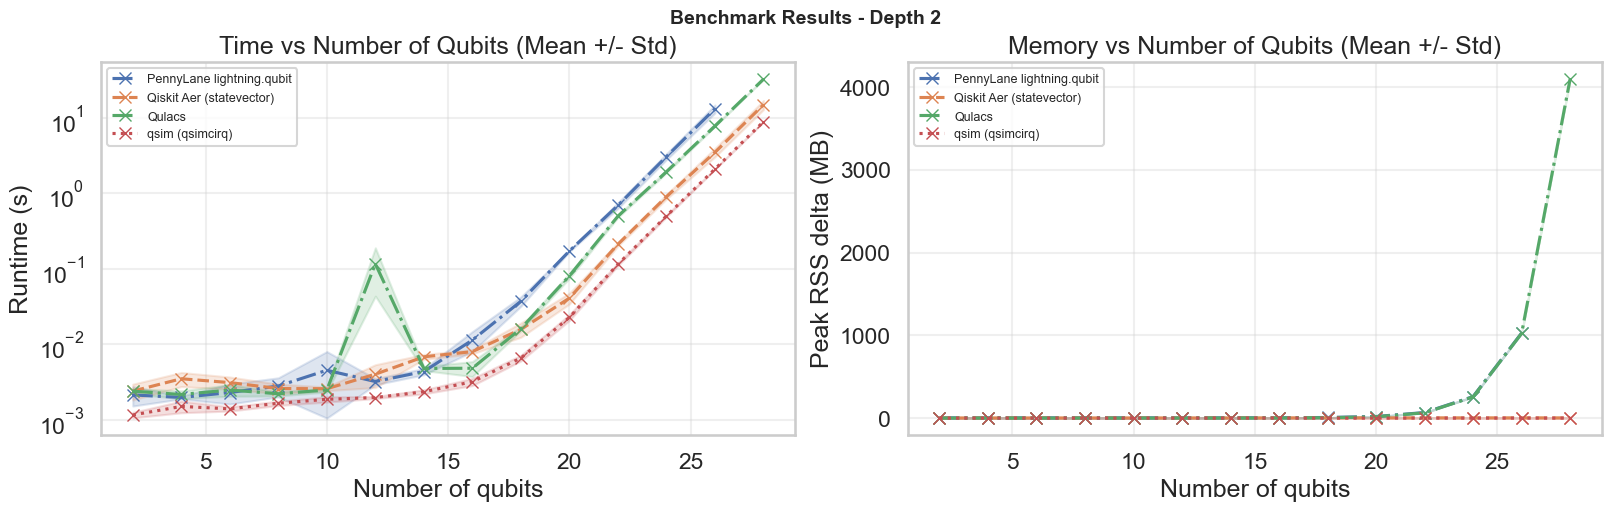

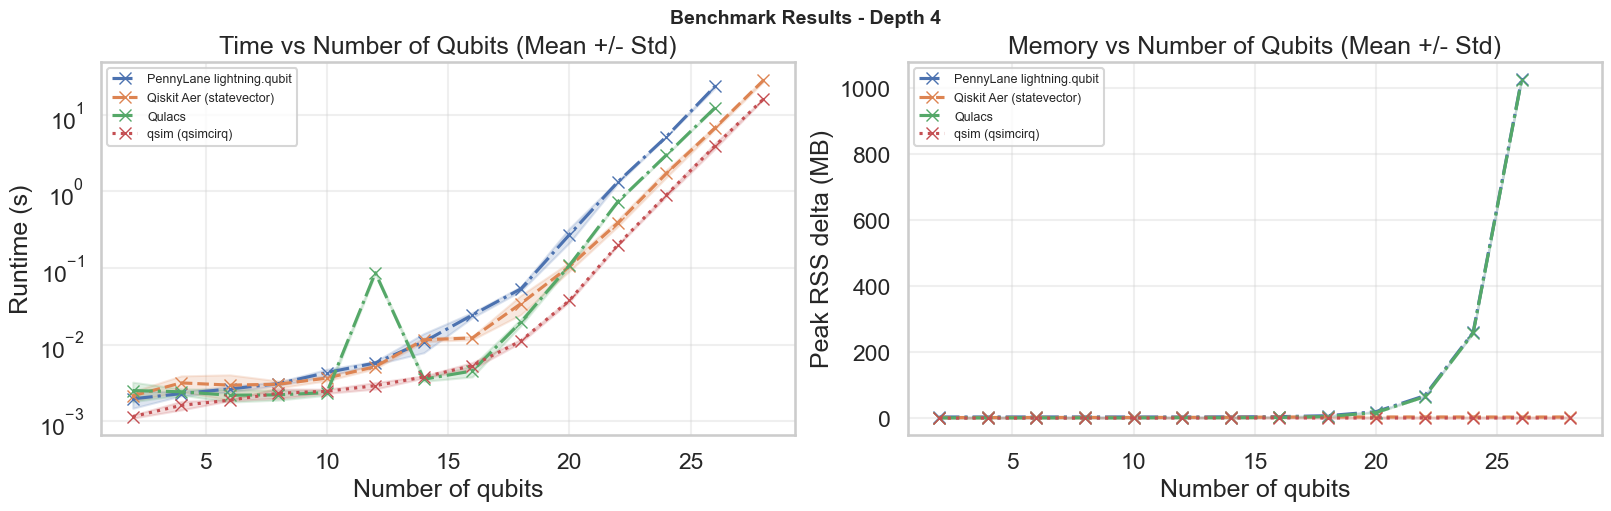

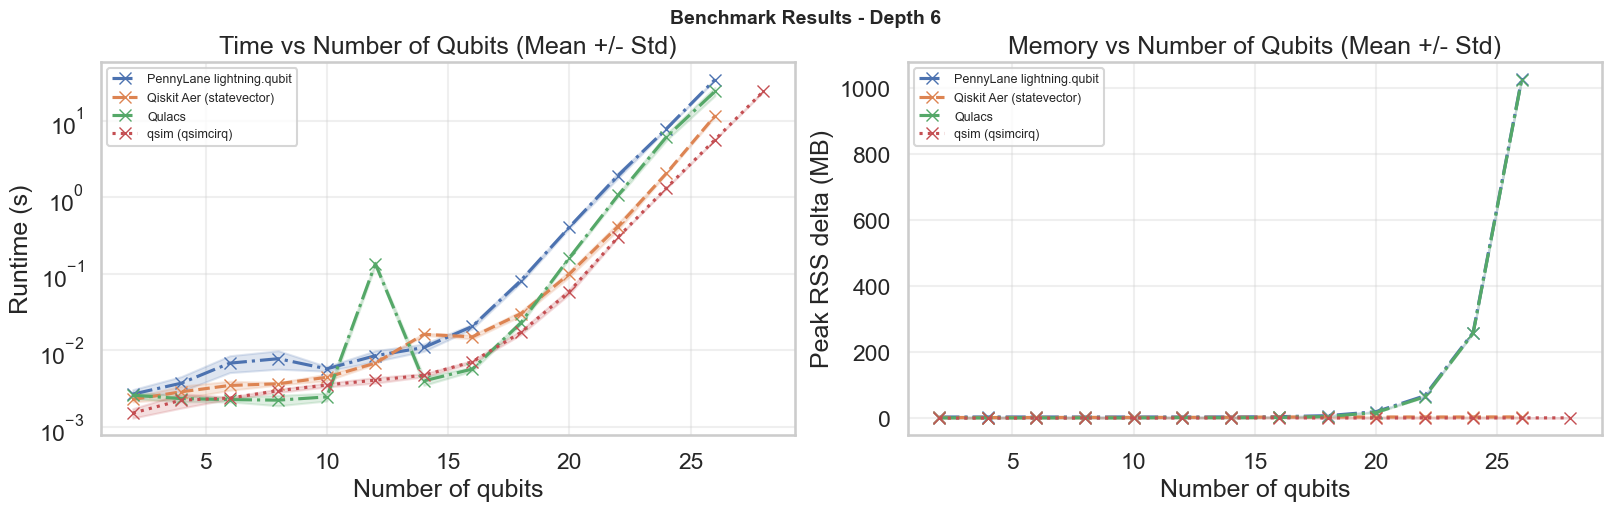

In [7]:
out_dir = "benchmark_outputs"
raw_results_path = os.path.join(out_dir, "raw_results.csv")
runtime_mean_path = os.path.join(out_dir, "runtime_mean_table.csv")
runtime_std_path = os.path.join(out_dir, "runtime_std_table.csv")
memory_mean_path = os.path.join(out_dir, "memory_mean_table.csv")
memory_std_path = os.path.join(out_dir, "memory_std_table.csv")

if not os.path.exists(raw_results_path):
    raise FileNotFoundError(
        f"Missing {raw_results_path}. Run the benchmark/save cells first to generate CSV outputs."
    )

# Load saved CSVs so plotting does not depend on rerunning benchmarks.
plot_df = pd.read_csv(raw_results_path)

# Optional table loads (kept for quick inspection/use in later cells).
runtime_mean_table = pd.read_csv(runtime_mean_path, index_col=[0, 1]) if os.path.exists(runtime_mean_path) else None
runtime_std_table = pd.read_csv(runtime_std_path, index_col=[0, 1]) if os.path.exists(runtime_std_path) else None
memory_mean_table = pd.read_csv(memory_mean_path, index_col=[0, 1]) if os.path.exists(memory_mean_path) else None
memory_std_table = pd.read_csv(memory_std_path, index_col=[0, 1]) if os.path.exists(memory_std_path) else None

plot_df = plot_df[plot_df["status"] == "success"].copy()

# Ensure numeric columns are numeric after CSV roundtrip.
for col in ["depth", "qubits", "runtime_mean_s", "runtime_std_s", "memory_mean_mb", "memory_std_mb"]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=["depth", "qubits", "runtime_mean_s", "runtime_std_s", "memory_mean_mb", "memory_std_mb"])

backend_list = sorted(plot_df["backend"].unique())
depth_list = sorted(plot_df["depth"].astype(int).unique())
palette = sns.color_palette(n_colors=len(backend_list))
color_map = {b: palette[i] for i, b in enumerate(backend_list)}
linestyle_map = {b: ("-.", "--", "-.", ":")[i % 4] for i, b in enumerate(backend_list)}

for depth in depth_list:
    depth_df = plot_df[plot_df["depth"] == depth]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    fig.suptitle(f"Benchmark Results - Depth {depth}", fontsize=14, fontweight="bold")

    for i, backend in enumerate(backend_list):
        sub = depth_df[depth_df["backend"] == backend].sort_values("qubits")
        if sub.empty:
            continue

        x = sub["qubits"].to_numpy()
        rt_mean = sub["runtime_mean_s"].to_numpy()
        rt_std = sub["runtime_std_s"].to_numpy()
        mem_mean = sub["memory_mean_mb"].to_numpy()
        mem_std = sub["memory_std_mb"].to_numpy()

        axes[0].plot(x, rt_mean, marker="x", color=color_map[backend], linestyle=linestyle_map[backend], label=backend)
        axes[0].fill_between(
            x,
            np.maximum(rt_mean - rt_std, 1e-12),
            rt_mean + rt_std,
            color=color_map[backend],
            alpha=0.18,
        )

        axes[1].plot(x, mem_mean, marker="x", color=color_map[backend], linestyle=linestyle_map[backend], label=backend)
        axes[1].fill_between(
            x,
            np.maximum(mem_mean - mem_std, 0.0),
            mem_mean + mem_std,
            color=color_map[backend],
            alpha=0.18,
        )

    axes[0].set_title("Time vs Number of Qubits (Mean +/- Std)")
    axes[0].set_ylabel("Runtime (s)")
    axes[0].set_xlabel("Number of qubits")
    axes[0].set_yscale("log")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Memory vs Number of Qubits (Mean +/- Std)")
    axes[1].set_ylabel("Peak RSS delta (MB)")
    axes[1].set_xlabel("Number of qubits")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.show()

# Findings and discussions

### Runtime: 
- Qubit count is the dominant runtime driver (as expected). Across all backends, runtime remains relatively low at small qubit counts and then rises sharply once qubit counts enters the upper part of the tested range. This effect is much stronger than the effect of increasing depther from $d=2$ to $d=6$
- Depth still matters, but mainly as a secondary scaling factor. Increasing depth shifts the runtime curves upward, especially in the mid-to-high qubit regime, but it does not change the overall ranking as strongly as qubit count does. Another trend is that at the highest tested qubit count ($q=28$), multiple backends remain within the $60 s$ timeout at $d=2$, whereas at larger depths qsim is the only backend that continues to do so reliably. Operationally, this indicates that qsim has the strongest runtime headroom under the most demanding benchmark cases considered here.
- qsimcirq is the strongest runtime performer overall. It gives the lowest runtime across most or all of the tested range and remains especially strong as qubit count increases, making it the best candidate for fast CPU-based iteration.
- Qiskit Aer is generally competitive but not the fastest. It tracks the leading group reasonably well at low-to-moderate qubit counts, but is consistently behind qsimcirq in the larger tested regime.
- PennyLane lightning.qubit is the slowest overall in this benchmark. Its runtime grows more quickly than the other backends as qubit count increases, so it is less attractive as the default simulator for repeated VQC-style experimentation.
- Qulacs is competitive in parts of the tested range, but shows an isolated runtime spike around 12 qubits. Because this spike does not appear to define the broader scaling trend, it is better treated as an outlier or backend-specific anomaly rather than as a reliable performance breakpoint.

### Memory:
- Qubit count is again the main driver of memory pressure. This is most visible for Qulacs and Pennylane lightning.qubit, where the reported peak RSS grows sharply in the high-qubit regime.
- Qulacs and Pennylane lightning.qubit shows the earliest and strongest memory growth. In the tested CPU environment, it appears to hit practical memory pressure sooner than the other backends, which weakens its suitability for larger exact simulations despite reasonable runtime in some regimes.
- The other backends show near-flat reported RSS deltas across most of the tested range. Since each benchmark case is run is a fresh subprocess, the flat reported RSS deltas are less likely to be caused by cross-run allocator reuse. However, they should still be interpreted cautiously, as process-level RSS deltas remain an operational metric and may not fully capture the true simulator memory footprint. The strongest conclusion is therefore comparative rather than absolute.
- Memory results should therefore be interpreted operationally rather than as exact absolute memory footprints. The strongest robust conclusion is comparative: Qulacs and Pennylane lightning.qubit shows much more visible process-level memory growth than the other backends in this setup.

## Main takeaways: 
### Which simulator is best for which scenarios?
- Qulacs and Pennylane lightning.qubit may still be acceptable in smaller regimes, but is less suitable for larger exact simulations because it shows the earliest practical memory growth.
- qsim is more attractive in larger qubit regimes because it combines best runtime with no comparable memory blow-up
- Aer looks like a reasonable second choice if we value ecosystem familiarity and want more balanced behaviour.
### Where does each hit its scalability limit?
- Qulacs and Pennylane lightning.qubit hits its practical scalability limit earliest, because memory rises sharply in the upper qubit regime.
- For qsim and Aer, the limit is more about runtime practicality in the tested range. Here, qsim scales better than Aer with runtimes within the timeout of $60s$ at high depths ($d=6$).
- For Qulacs and Pennylane lightning.qubit, the limit is more clearly a memory-pressure issue.
### Recommendations: 
- Clear winner: qsim
- Default backend for fast iteration should be driven mostly by runtime. So, fast iteration default is qsim because it is the fastest with lowest memory growth in our setup.
- Backend for "precise computations at higher qubit counts": Since all are exact simulators, "precise" here really means: most operationally practical exact backend at larger qubit counts. So memory matters a lot here:
    - qsim is still the best recommendation
    - not only because of runtime, but also because it does not show the strong memory growth seen in Qulacs and Pennylane lightning.qubit. 
    - also qsim scales better than Aer at high qubit counts and deep circuits.
### Caveats
Memory is peak RSS delta measured in fresh subprocesses (peak minus baseline), not allocator-level exact peak.
Results are hardware- and version-dependent; rerun this notebook in the corresponding deployment environment for final backend selection.
For production policy, combine these speed/memory results with numerical validation on target workloads.

## Additional Study (Overall summary)

To support a practical simulator recommendation, we summarize performance in two regimes: fast iteration (q<=10), and a higher qubit exact simulation (q>=20). For each regime, we report both overall and depth-wise comparisons across backends using success rate, runtime, and memory. We also record the maximum successful qubit count reached by each backend, since scalability limits are as important as raw speed in determining which simulator is most useful in practice

In [8]:
runtime_col = "runtime_mean_s"

# Try to auto-detect a memory column
memory_candidates = [
    "memory_mean_mb",
    "peak_rss_delta_mb",
    "peak_rss_delta_mean_mb",
    "memory_mb",
    "rss_delta_mb",
]
memory_col = next((c for c in memory_candidates if c in results_df.columns), None)

fast_qubit_cutoff = 10
high_qubit_cutoff = 20

# ----------------------------
# Helper functions
# ----------------------------
def add_success_counts(df: pd.DataFrame, group_cols):
    """Return attempted/success counts from all runs."""
    out = (
        df.groupby(group_cols, as_index=False)
        .agg(
            attempted_cases=("status", "size"),
            successful_cases=("status", lambda s: (s == "success").sum()),
        )
    )
    out["success_rate"] = out["successful_cases"] / out["attempted_cases"]
    return out


def summarize_success_metrics(success_df: pd.DataFrame, group_cols, runtime_col: str, memory_col: str | None):
    """Summarize runtime/memory on successful runs only."""
    agg_dict = {
        "mean_runtime_s": (runtime_col, "mean"),
        "median_runtime_s": (runtime_col, "median"),
    }
    if memory_col is not None:
        agg_dict["mean_memory_mb"] = (memory_col, "mean")
        agg_dict["median_memory_mb"] = (memory_col, "median")

    return success_df.groupby(group_cols, as_index=False).agg(**agg_dict)


def build_regime_tables(results_df: pd.DataFrame, qubit_mask: pd.Series, regime_name: str):
    """Build overall and depth-wise ranking tables for a qubit regime."""
    regime_all = results_df.loc[qubit_mask].copy()
    regime_success = regime_all[regime_all["status"] == "success"].copy()

    sort_cols = ["success_rate", "mean_runtime_s"]
    ascending = [False, True]
    if memory_col is not None:
        sort_cols.append("mean_memory_mb")
        ascending.append(True)

    # Overall summary
    overall_counts = add_success_counts(regime_all, ["backend"])
    overall_metrics = summarize_success_metrics(regime_success, ["backend"], runtime_col, memory_col)
    overall = overall_counts.merge(overall_metrics, on="backend", how="left")

    overall = overall.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
    overall.insert(0, "rank", np.arange(1, len(overall) + 1))
    overall.insert(0, "regime", regime_name)

    overall_cols = [
        "regime", "rank", "backend",
        "attempted_cases", "successful_cases", "success_rate",
        "mean_runtime_s", "median_runtime_s",
    ]
    if memory_col is not None:
        overall_cols += ["mean_memory_mb", "median_memory_mb"]
    overall = overall[overall_cols]

    # Depth-wise summary
    depth_counts = add_success_counts(regime_all, ["depth", "backend"])
    depth_metrics = summarize_success_metrics(regime_success, ["depth", "backend"], runtime_col, memory_col)
    depthwise = depth_counts.merge(depth_metrics, on=["depth", "backend"], how="left")

    depthwise = depthwise.sort_values(
        ["depth"] + sort_cols,
        ascending=[True] + ascending
    ).reset_index(drop=True)

    depthwise["rank"] = depthwise.groupby("depth").cumcount() + 1
    depthwise.insert(0, "regime", regime_name)

    depthwise_cols = [
        "regime", "depth", "rank", "backend",
        "attempted_cases", "successful_cases", "success_rate",
        "mean_runtime_s", "median_runtime_s",
    ]
    if memory_col is not None:
        depthwise_cols += ["mean_memory_mb", "median_memory_mb"]
    depthwise = depthwise[depthwise_cols]

    return overall, depthwise


# ----------------------------
# Base filtered data
# ----------------------------
success_df = results_df[results_df["status"] == "success"].copy()

# ----------------------------
# Scalability tables
# ----------------------------
scalability_overall = (
    success_df.groupby("backend", as_index=False)
    .agg(max_successful_qubits=("qubits", "max"))
    .sort_values("max_successful_qubits", ascending=False)
    .reset_index(drop=True)
)

scalability_by_depth = (
    success_df.groupby(["depth", "backend"], as_index=False)
    .agg(max_successful_qubits=("qubits", "max"))
    .sort_values(["depth", "max_successful_qubits", "backend"], ascending=[True, False, True])
    .reset_index(drop=True)
)

# ----------------------------
# Regime tables
# ----------------------------
fast_mask = results_df["qubits"] <= fast_qubit_cutoff
high_mask = results_df["qubits"] >= high_qubit_cutoff

fast_overall, fast_by_depth = build_regime_tables(
    results_df, fast_mask, regime_name=f"fast_iteration_q<={fast_qubit_cutoff}"
)

high_overall, high_by_depth = build_regime_tables(
    results_df, high_mask, regime_name=f"high_qubit_q>={high_qubit_cutoff}"
)

# ----------------------------
# Display
# ----------------------------

print("Scalability overall:")
display(scalability_overall)

print("\nScalability by depth:")
display(scalability_by_depth)

print(f"\nFast-iteration overall ranking (q <= {fast_qubit_cutoff}):")
display(fast_overall)

print(f"\nFast-iteration ranking by depth (q <= {fast_qubit_cutoff}):")
display(fast_by_depth)

print(f"\nHigh-qubit overall ranking (q >= {high_qubit_cutoff}):")
display(high_overall)

print(f"\nHigh-qubit ranking by depth (q >= {high_qubit_cutoff}):")
display(high_by_depth)

Scalability overall:


,backend,max_successful_qubits
0,Qiskit Aer (statevector),28
1,Qulacs,28
2,qsim (qsimcirq),28
3,PennyLane lightning.qubit,26



Scalability by depth:


,depth,backend,max_successful_qubits
0,2,Qiskit Aer (statevector),28
1,2,Qulacs,28
2,2,qsim (qsimcirq),28
3,2,PennyLane lightning.qubit,26
4,4,Qiskit Aer (statevector),28
5,4,qsim (qsimcirq),28
6,4,PennyLane lightning.qubit,26
7,4,Qulacs,26
8,6,qsim (qsimcirq),28
9,6,PennyLane lightning.qubit,26



Fast-iteration overall ranking (q <= 10):


...

,regime,depth,rank,backend,attempted_cases,successful_cases,success_rate,mean_runtime_s,median_runtime_s,mean_memory_mb,median_memory_mb
0,fast_iteration_q<=10,2,1,qsim (qsimcirq),5,5,1.0,0.001521,0.001508,0.364219,0.371094
1,fast_iteration_q<=10,2,2,Qulacs,5,5,1.0,0.002352,0.002397,1.167969,1.169531
2,fast_iteration_q<=10,2,3,PennyLane lightning.qubit,5,5,1.0,0.002755,0.002303,3.767031,3.768750
3,fast_iteration_q<=10,2,4,Qiskit Aer (statevector),5,5,1.0,0.002842,0.002602,2.319844,2.317969
4,fast_iteration_q<=10,4,1,qsim (qsimcirq),5,5,1.0,0.001883,0.001882,0.408594,0.403906
5,fast_iteration_q<=10,4,2,Qulacs,5,5,1.0,0.002336,0.002361,1.176719,1.191406
6,fast_iteration_q<=10,4,3,PennyLane lightning.qubit,5,5,1.0,0.002856,0.002635,3.816875,3.792969
7,fast_iteration_q<=10,4,4,Qiskit Aer (statevector),5,5,1.0,0.002991,0.003037,2.300312,2.367188
8,fast_iteration_q<=10,6,1,Qulacs,5,5,1.0,0.002366,0.002326,1.174063,1.179688
9,fast_iteration_q<=10,6,2,qsim (qsimcirq),5,5,1.0,0.002508,0.002363,0.482344,0.453906



High-qubit overall ranking (q >= 20):


,regime,rank,backend,attempted_cases,successful_cases,success_rate,mean_runtime_s,median_runtime_s,mean_memory_mb,median_memory_mb
0,high_qubit_q>=20,1,qsim (qsimcirq),15,15,1.000000,4.280835,0.900318,0.767708,0.734375
1,high_qubit_q>=20,2,Qiskit Aer (statevector),15,14,0.933333,5.055749,1.311448,3.668415,3.816406
2,high_qubit_q>=20,3,Qulacs,15,13,0.866667,6.942444,1.930382,630.085757,257.316406
3,high_qubit_q>=20,4,PennyLane lightning.qubit,15,12,0.800000,7.655416,2.483021,343.884049,163.948828



High-qubit ranking by depth (q >= 20):


,regime,depth,rank,backend,attempted_cases,successful_cases,success_rate,mean_runtime_s,median_runtime_s,mean_memory_mb,median_memory_mb
0,high_qubit_q>=20,2,1,qsim (qsimcirq),5,5,1.0,2.317772,0.500419,0.535000,0.526563
1,high_qubit_q>=20,2,2,Qiskit Aer (statevector),5,5,1.0,3.895992,0.902154,3.354375,3.444531
2,high_qubit_q>=20,2,3,Qulacs,5,5,1.0,8.535207,1.930382,1092.329063,257.316406
3,high_qubit_q>=20,2,4,PennyLane lightning.qubit,5,4,0.8,4.262507,1.873157,343.856836,163.865625
4,high_qubit_q>=20,4,1,qsim (qsimcirq),5,5,1.0,4.239345,0.900318,0.764687,0.734375
5,high_qubit_q>=20,4,2,Qiskit Aer (statevector),5,5,1.0,7.451956,1.720743,3.776562,3.845312
6,high_qubit_q>=20,4,3,Qulacs,5,4,0.8,4.059049,1.870525,341.210547,161.253125
7,high_qubit_q>=20,4,4,PennyLane lightning.qubit,5,4,0.8,7.599538,3.268154,343.903711,164.026172
8,high_qubit_q>=20,6,1,qsim (qsimcirq),5,5,1.0,6.285388,1.315055,1.003437,0.972656
9,high_qubit_q>=20,6,2,Qiskit Aer (statevector),5,4,0.8,3.510185,1.228615,3.925781,3.880859


### Take-aways 
These summary tables show that qsim is the strongest overall backend in this benchmark. It is the fastest in the fast-iteration regime, the only backend with a perfect success rate in the higher-qubit regime, and one of the most favorable backends in terms of observed memory usage. Qiskit Aer is the next strongest option overall, particularly as a balanced fallback with good scalability. Qulacs is competitive at smaller sizes but shows the earliest and strongest memory pressure at larger qubit counts, while PennyLane lightning.qubit is consistently slower and less scalable in this CPU-only exact-simulation setting.

### Below is a smoke-test to test each backends and their outputs

In [9]:
# Smoke test: verify constant-size observable outputs for each backend on a tiny instance.
test_n = 4
test_d = 2
test_params = make_params(test_n, test_d, seed=SEED)

smoke_backend_specs = [
    ("Qiskit Aer (statevector)", "exact", lambda n, d, p: build_qiskit_runner(n, d, p, method="statevector")),
    ("PennyLane lightning.qubit", "exact", build_pennylane_runner),
    ("Qulacs", "exact", build_qulacs_runner),
    ("qsim (qsimcirq)", "exact", build_qsim_runner),
]

for backend_name, strategy_name, builder in smoke_backend_specs:
    runner = builder(test_n, test_d, test_params)
    value = runner()
    arr = np.atleast_1d(np.asarray(value, dtype=float))
    print(f"{backend_name:30s} | strategy={strategy_name:10s} | output_shape={arr.shape} | values={arr}")

Qiskit Aer (statevector)       | strategy=exact      | output_shape=(1,) | values=[0.1011865]
PennyLane lightning.qubit      | strategy=exact      | output_shape=(1,) | values=[0.1011865]
Qulacs                         | strategy=exact      | output_shape=(1,) | values=[0.1011865]
qsim (qsimcirq)                | strategy=exact      | output_shape=(1,) | values=[0.10118613]
